In [17]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from plot_config import (
    get_condition,
    apply_style,
    strip_spines,
    label_panel,
    set_n_ticks,
    save_figure,
)

apply_style()

In [18]:
# ============================================================
# CONFIG -- tunable knobs
# ============================================================

from pathlib import Path

# Condition key (plot_config.py) -> simulation output directory.
DATA_DIRS = {
    "control": Path(
        "/data/hdrive/phd/results/train/control/RSV90C250uM_20_p20hz"
    ),
    "ad_5x_ryr": Path(
        "/data/hdrive/phd/results/train/AD/RSV90C750uM_20_p20hz_5xryr"
    ),
    "ad_half_ryr": Path(
        "/data/hdrive/phd/results/train/AD/RSV90C750uM_20_p20hz_1_2xryr"
    ),
}

# Stimulus protocol.
N_PULSES = 20
FREQ_HZ = 20
FIRST_PULSE_TIME = 0.002  # s


FIGSIZE = (15, 10.5)
SAVE_NAME = "fig6_RyR_train.png"

MARKERSIZE = 6
CAPSIZE = 3
ELINEWIDTH = 1.2
FIT_LINEWIDTH = 1.8
N_FIT_SAMPLES = 200


N_TICKS = 3
PULSE_XTICKS = [1, N_PULSES // 2, N_PULSES]

X_TICKS = {
    "az_peak": PULSE_XTICKS,
    "az_base": PULSE_XTICKS,
    "cyto_peak": PULSE_XTICKS,
    "cyto_base": PULSE_XTICKS,
    "er_peak": PULSE_XTICKS,
    "ryr_flux": None,
    "pr_vs_az": None,
    "fac_vs_az": None,
    "fac_vs_pulse": PULSE_XTICKS,
}

Y_TICKS = {
    "az_peak": [10, 25, 40],
    "az_base": [5, 20, 35],
    "cyto_peak": [3, 8.5, 14],
    "cyto_base": [3, 7, 11],
    "er_peak": [23, 380, 750],
    "ryr_flux": None,
    "pr_vs_az": [0.1, 0.4, 0.8],
    "fac_vs_az": [0, 3, 6],
    "fac_vs_pulse": [0, 3, 6],
}

In [19]:
# ============================================================
# DATA LOADING
# ============================================================


def load_trace(fname):
    """Return (time_s, value) for a two-column whitespace-delimited trace."""
    data = np.loadtxt(fname)
    return data[:, 0], data[:, 1]


def load_ryr_flux(fname):
    """ryrCaFlux.dat: col0=time(s), col1=outflux, col2=influx (molecules/s),
    per the convention established in Ca_flux/RyRcaflux.ipynb -- net flux =
    outflux - influx. Finer time resolution (10us) and smaller magnitude
    than ryrCaFluxRate.dat."""
    data = np.loadtxt(fname)
    t = data[:, 0]
    net = data[:, 1] - data[:, 2]
    return t, net


def load_result(fname):
    """result file: row 0 = means, row 1 = stds, each [Pr(20), Facilitation(20)]."""
    data = np.loadtxt(fname)
    means, stds = data[0], data[1]
    return {
        "pr_mean": means[:20],
        "pr_sd": stds[:20],
        "fac_mean": means[20:],
        "fac_sd": stds[20:],
    }


def _pulse_windows(first_pulse_time, freq, n_pulses, t_end):
    """(start, end) time window per pulse -- last window extends to t_end."""
    isi = 1.0 / freq
    starts = first_pulse_time + np.arange(n_pulses) * isi
    ends = np.append(starts[1:], t_end)
    return starts, ends


def extract_pulse_peaks(time, trace, first_pulse_time, freq, n_pulses):
    """Peak trace value within each pulse's window."""
    starts, ends = _pulse_windows(first_pulse_time, freq, n_pulses, time[-1])
    peaks = []
    for t0, t1 in zip(starts, ends):
        mask = (time >= t0) & (time < t1)
        peaks.append(np.max(trace[mask]) if np.any(mask) else np.nan)
    return np.asarray(peaks)


def extract_pulse_baselines(time, trace, first_pulse_time, freq, n_pulses):
    """Trace value at the sample immediately preceding each pulse onset."""
    starts, _ = _pulse_windows(first_pulse_time, freq, n_pulses, time[-1])
    baselines = []
    for t0 in starts:
        idx = max(np.searchsorted(time, t0) - 1, 0)
        baselines.append(trace[idx])
    return np.asarray(baselines)

In [20]:
# ============================================================
# LOAD DATA -- once per condition
# ============================================================

pulses = np.arange(1, N_PULSES + 1)
data = {}

for key, directory in DATA_DIRS.items():

    t_az, az = load_trace(directory / "CaConc")
    t_cyto, cyto = load_trace(directory / "pre_ca_conc.dat")
    cyto = cyto / 1000.0  # nM -> uM
    t_er, er = load_trace(directory / "er_ca_conc.dat")
    t_ryr, ryr_flux = load_ryr_flux(directory / "ryrCaFlux.dat")

    result = load_result(directory / "result")

    data[key] = {
        "az_peak": extract_pulse_peaks(t_az, az, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "az_base": extract_pulse_baselines(t_az, az, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "cyto_peak": extract_pulse_peaks(t_cyto, cyto, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "cyto_base": extract_pulse_baselines(t_cyto, cyto, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "er_peak": extract_pulse_peaks(t_er, er, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "ryr_flux_t_ms": t_ryr * 1000.0,
        "ryr_flux": ryr_flux / 100.0,  # molecules/s -> x100 molecules/s
        **result,
    }

In [21]:
# ============================================================
# ER DEPLETION RATE
# Steepest per-pulse decline in peak ER calcium (the row-1 ER panel data),
# i.e. the single sharpest pulse-to-pulse drop in er_peak. Reported in both
# uM/pulse (matches that panel's x-axis directly) and uM/s (dividing by the
# 20 Hz inter-pulse interval, for comparison to literature depletion rates).
# ============================================================

ISI_S = 1.0 / FREQ_HZ

depletion_info = {}

print("Peak ER Ca depletion rate (steepest single-pulse drop):")
for key in DATA_DIRS:
    cond = get_condition(key)
    er_peak = data[key]["er_peak"]
    per_pulse_drop = -np.diff(er_peak)  # positive = declining
    steepest = np.argmax(per_pulse_drop)
    rate_per_pulse = per_pulse_drop[steepest]
    rate_per_s = rate_per_pulse / ISI_S
    depletion_info[key] = {
        "steepest_idx": steepest,
        "rate_per_pulse": rate_per_pulse,
        "rate_per_s": rate_per_s,
    }
    print(
        f"  {cond.label}: {rate_per_pulse:.2f} uM/pulse "
        f"({rate_per_s:.1f} uM/s), steepest between pulse "
        f"{steepest + 1} and {steepest + 2}"
    )

Peak ER Ca depletion rate (steepest single-pulse drop):
  Control: 37.31 uM/pulse (746.2 uM/s), steepest between pulse 2 and 3
  AD + 5× RyR: 273.44 uM/pulse (5468.9 uM/s), steepest between pulse 2 and 3
  AD + 1/2× RyR: 47.08 uM/pulse (941.6 uM/s), steepest between pulse 8 and 9


In [22]:
# ============================================================
# RyR FLUX: TIME TO HALF-MAX
# Time at which each condition's net RyR flux trace first reaches half its
# final (t=1s) value -- a compact measure of how front-loaded (fast) vs
# sustained (slow) RyR-mediated calcium release is across the train.
# ============================================================

half_max_info = {}

print("RyR net flux: time to half-maximum:")
for key in DATA_DIRS:
    cond = get_condition(key)
    t_ms = data[key]["ryr_flux_t_ms"]
    y = data[key]["ryr_flux"]
    half = y[-1] / 2.0
    idx = int(np.argmax(y >= half))
    half_max_info[key] = {"t_ms": t_ms[idx], "y": y[idx]}
    print(f"  {cond.label}: {t_ms[idx]:.1f} ms")

RyR net flux: time to half-maximum:
  Control: 271.4 ms
  AD + 5× RyR: 95.1 ms
  AD + 1/2× RyR: 482.0 ms


In [23]:
# ============================================================
# FIGURE-BUILDING HELPERS
# ============================================================


def apply_xticks(ax, key, vmin, vmax):
    override = X_TICKS.get(key)
    if override is not None:
        ax.set_xticks(override)
    else:
        set_n_ticks(ax, vmin, vmax, n=N_TICKS, axis="x")


def apply_yticks(ax, key, vmin, vmax):
    override = Y_TICKS.get(key)
    if override is not None:
        ax.set_yticks(override)
    else:
        set_n_ticks(ax, vmin, vmax, n=N_TICKS, axis="y")


def trace_panel(ax, letter, field, ylabel, tick_key):
    """Single calcium trace (peak or baseline) vs pulse, one line per condition."""
    for key in DATA_DIRS:
        cond = get_condition(key)
        ax.plot(
            pulses, data[key][field],
            color=cond.color, linestyle="-", marker=cond.marker,
            markersize=MARKERSIZE, markerfacecolor=cond.color, markeredgecolor=cond.color,
            alpha=cond.alpha, zorder=cond.zorder,
        )
    ax.set_xlabel("Pulse Number")
    ax.set_ylabel(ylabel)
    apply_xticks(ax, tick_key, pulses.min(), pulses.max())
    all_y = np.concatenate([data[k][field] for k in DATA_DIRS])
    apply_yticks(ax, tick_key, all_y.min(), all_y.max())
    ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
    strip_spines(ax)
    label_panel(ax, letter)


def flux_trace_panel(ax, letter, t_field, y_field, ylabel, tick_key):
    """Raw continuous time-domain trace."""
    for key in DATA_DIRS:
        cond = get_condition(key)
        ax.plot(
            data[key][t_field], data[key][y_field],
            color=cond.color, linestyle="-",
            alpha=cond.alpha, zorder=cond.zorder,
        )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(ylabel)
    all_t = np.concatenate([data[k][t_field] for k in DATA_DIRS])
    apply_xticks(ax, tick_key, all_t.min(), all_t.max())
    all_y = np.concatenate([data[k][y_field] for k in DATA_DIRS])
    
    apply_yticks(ax, tick_key, max(0.0, all_y.min()), all_y.max())
    ax.set_ylim(bottom=0)
    strip_spines(ax)
    label_panel(ax, letter)


def stat_panel(ax, letter, x_field, y_field, y_sd_field, xlabel, ylabel, tick_key,
               x_is_pulse=False):
    """Connected line + error bars per condition (no fit overlay)."""
    for key in DATA_DIRS:
        cond = get_condition(key)
        x = pulses if x_is_pulse else data[key][x_field]
        y = data[key][y_field]
        yerr = data[key][y_sd_field]

        ax.errorbar(
            x, y, yerr=yerr,
            color=cond.color, marker=cond.marker, linestyle=cond.linestyle,
            markersize=MARKERSIZE, capsize=CAPSIZE, elinewidth=ELINEWIDTH,
            alpha=cond.alpha, zorder=cond.zorder,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    x_all = pulses if x_is_pulse else np.concatenate([data[k][x_field] for k in DATA_DIRS])
    apply_xticks(ax, tick_key, x_all.min(), x_all.max())
    y_all = np.concatenate([data[k][y_field] for k in DATA_DIRS])
    apply_yticks(ax, tick_key, y_all.min(), y_all.max())
    if x_is_pulse:
        ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
    strip_spines(ax)
    label_panel(ax, letter)

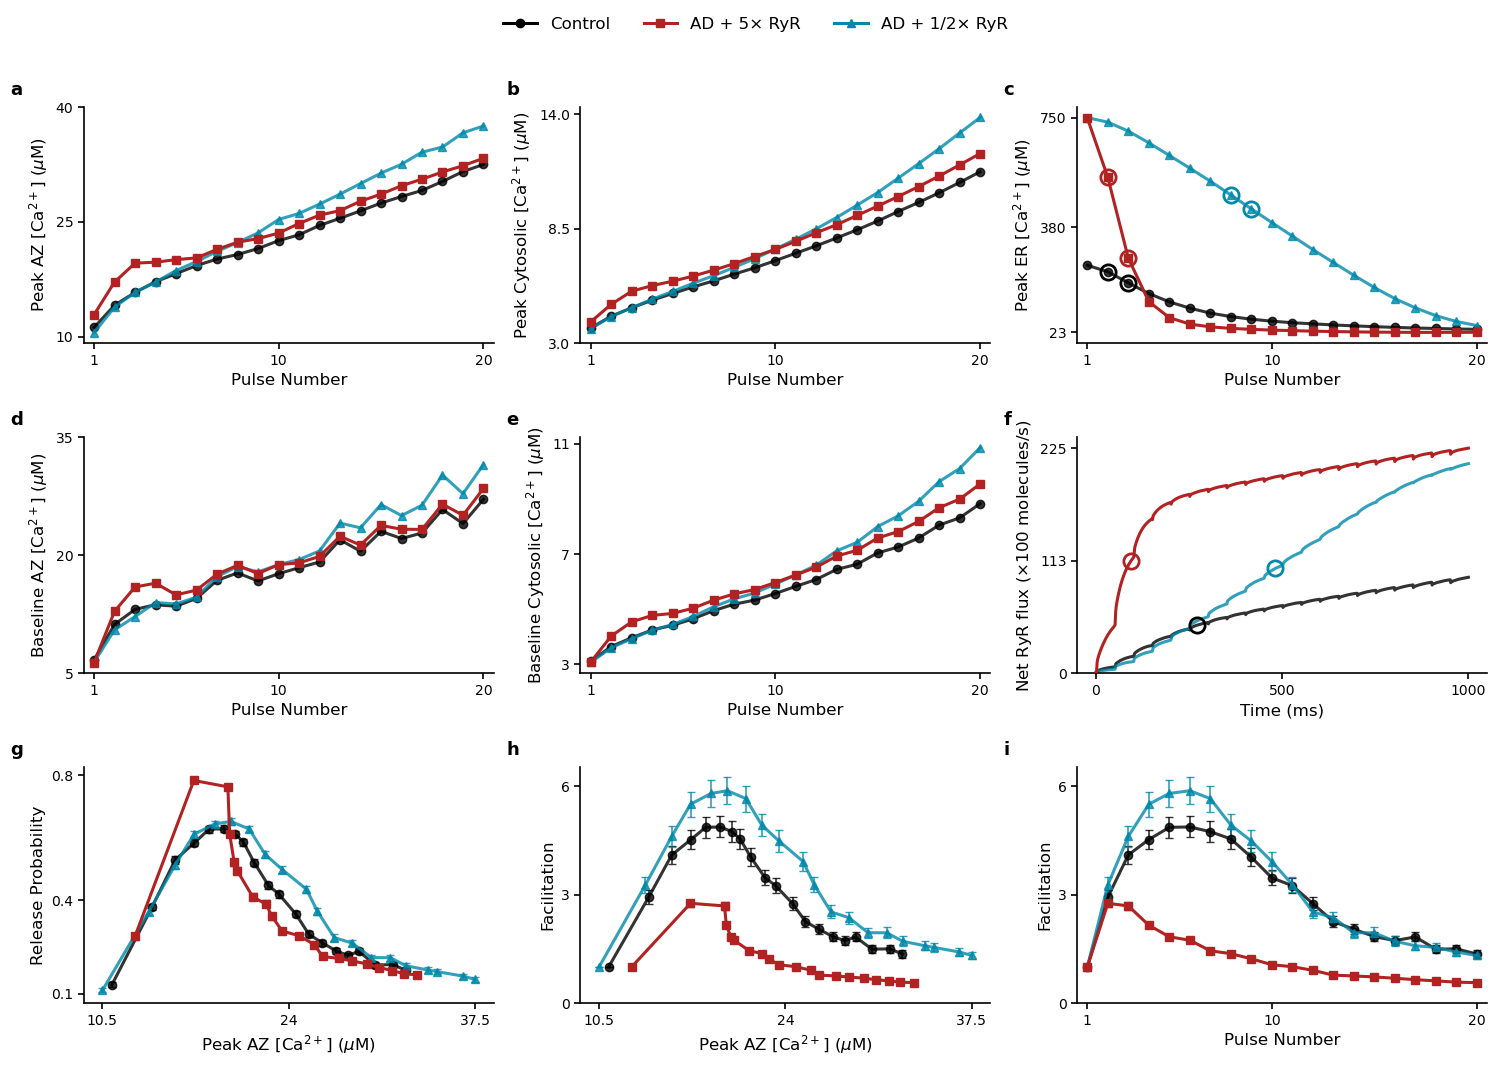

In [24]:
# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=FIGSIZE)

# Row 1: peak calcium per pool
trace_panel(axes[0, 0], "a", "az_peak", r"Peak AZ [Ca$^{2+}$] ($\mu$M)", "az_peak")
trace_panel(axes[0, 1], "b", "cyto_peak", r"Peak Cytosolic [Ca$^{2+}$] ($\mu$M)", "cyto_peak")
trace_panel(axes[0, 2], "c", "er_peak", r"Peak ER [Ca$^{2+}$] ($\mu$M)", "er_peak")


for key in DATA_DIRS:
    cond = get_condition(key)
    idx = depletion_info[key]["steepest_idx"]
    axes[0, 2].plot(
        pulses[idx:idx + 2], data[key]["er_peak"][idx:idx + 2],
        linestyle="none", marker="o", markersize=MARKERSIZE + 5,
        markerfacecolor="none", markeredgecolor=cond.color, markeredgewidth=2,
        zorder=cond.zorder + 1,
    )

# Row 2: baseline calcium per pool (AZ, cytosolic), raw RyR Ca flux trace
trace_panel(axes[1, 0], "d", "az_base", r"Baseline AZ [Ca$^{2+}$] ($\mu$M)", "az_base")
trace_panel(axes[1, 1], "e", "cyto_base", r"Baseline Cytosolic [Ca$^{2+}$] ($\mu$M)", "cyto_base")
flux_trace_panel(
    axes[1, 2], "f", "ryr_flux_t_ms", "ryr_flux",
    r"Net RyR flux ($\times$100 molecules/s)", "ryr_flux",
)

# Mark each condition's time-to-half-max (computed above) with a hollow ring.
for key in DATA_DIRS:
    cond = get_condition(key)
    info = half_max_info[key]
    axes[1, 2].plot(
        info["t_ms"], info["y"],
        linestyle="none", marker="o", markersize=MARKERSIZE + 5,
        markerfacecolor="none", markeredgecolor=cond.color, markeredgewidth=2,
        zorder=cond.zorder + 1,
    )

# Row 3: release statistics, connected line + error bars
stat_panel(
    axes[2, 0], "g", "az_peak", "pr_mean", "pr_sd",
    r"Peak AZ [Ca$^{2+}$] ($\mu$M)", "Release Probability", "pr_vs_az",
)
stat_panel(
    axes[2, 1], "h", "az_peak", "fac_mean", "fac_sd",
    r"Peak AZ [Ca$^{2+}$] ($\mu$M)", "Facilitation", "fac_vs_az",
)
stat_panel(
    axes[2, 2], "i", None, "fac_mean", "fac_sd",
    "Pulse Number", "Facilitation", "fac_vs_pulse",
    x_is_pulse=True,
)

# Condition color key, above the whole figure
condition_handles = [
    Line2D([0], [0], color=get_condition(k).color, marker=get_condition(k).marker,
           linestyle="-", markersize=MARKERSIZE, label=get_condition(k).label)
    for k in DATA_DIRS
]
fig.legend(
    handles=condition_handles, loc="upper center", ncol=3,
    frameon=False, bbox_to_anchor=(0.5, 1.02),
)

plt.tight_layout(rect=(0, 0, 1, 0.96), h_pad=1.5)

save_figure(fig, SAVE_NAME)

plt.show()